# Week 3 — Machine Learning: NPV Prediction
## Project 04: Long-term Mine Planning — Simultaneous NPV and Throughput Optimization

### Objectives
- Engineer features: cumulative ore by period, grade smoothness, strip ratio
- Train Random Forest + XGBoost to predict NPV per block
- 5-fold cross-validation
- Feature importance: which block characteristics drive NPV?

## 0. Imports

In [4]:
import sys
!{sys.executable} -m pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 6.2 MB/s eta 0:00:17
    --------------------------------------- 2.1/101.7 MB 4.6 MB/s eta 0:00:22
   - -------------------------------------- 2.9/101.7 MB 4.4 MB/s eta 0:00:23
   - -------------------------------------- 3.7/101.7 MB 4.1 MB/s eta 0:00:25
   - -------------------------------------- 3.9/101.7 MB 3.6 MB/s eta 0:00:28
   - -------------------------------------- 4.7/101.7 MB 3.6 MB/s eta 0:00:27
   -- ------------------------------------- 5.5/101.7 MB 3.7 MB/s eta 0:00:27
   -- ------------------------------------- 6.6/101.7 MB 3.7 MB/s eta 0:00:26
   -- ------------------------------------- 7.3/101.7 MB 3.7 MB/s eta 0:00:26
   --- ------------------------------------ 8.1/101.7 MB 3.7 MB/s eta 0:00:26



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import pickle

np.random.seed(42)
os.makedirs('models', exist_ok=True)
print('Libraries loaded ✓')

Libraries loaded ✓


Load Data from Week 2

In [39]:
# Load the base dataframe
df = pd.read_csv('block_model_with_simulation.csv')
print(f'Loaded CSV: {df.shape[0]} blocks.')

# Load the raw Monte Carlo scenario matrices
mc_data = np.load('monte_carlo_matrices.npz')
grade_matrix = mc_data['grade_matrix']
npv_matrix   = mc_data['npv_matrix']
N_SCENARIOS  = grade_matrix.shape[1]

print(f'Loaded Matrices: {N_SCENARIOS} scenarios per block.')

Loaded CSV: 500 blocks.
Loaded Matrices: 200 scenarios per block.


Feature Engineering

In [43]:
scenario_data = []
periods = sorted(df['period_available'].unique())

for p in periods:
    # Get index positions for all blocks mined in this specific period
    idx = df.index[df['period_available'] == p].tolist()
    
    # Static Period Features (Same across all 200 scenarios)
    tonnage = df.loc[idx, 'tonnage_kt'].values
    cum_ore = tonnage.sum()
    avg_strip_ratio = df.loc[idx, 'stripping_ratio'].mean() 
    
    # Loop through the 200 parallel realities for this specific period
    for s in range(N_SCENARIOS):
        # Extract the simulated reality for these specific blocks
        sim_grades = grade_matrix[idx, s]
        
        sim_block_npvs = npv_matrix[idx, s] 
        
        # Scenario-specific feature: grade volatility in THIS reality
        grade_smoothness = sim_grades.std()
        # Target: Total Period NPV 
        total_period_npv = np.sum(sim_block_npvs)
        
        # Append as a new valid data point
        scenario_data.append({
            'period': p,
            'scenario_id': s,
            'cumulative_ore_by_period': cum_ore,
            'grade_smoothness': grade_smoothness,
            'strip_ratio': avg_strip_ratio,
            'target_period_npv': total_period_npv
        })

ml_df = pd.DataFrame(scenario_data)
print(f"Dataset built! Shape: {ml_df.shape} (10 Periods × 200 Scenarios)")
print(ml_df.head())

Dataset built! Shape: (2000, 6) (10 Periods × 200 Scenarios)
   period  scenario_id  cumulative_ore_by_period  grade_smoothness  \
0       1            0                   26176.5          0.189220   
1       1            1                   26176.5          0.205072   
2       1            2                   26176.5          0.201787   
3       1            3                   26176.5          0.175169   
4       1            4                   26176.5          0.177824   

   strip_ratio  target_period_npv  
0     2.716792       1.690857e+09  
1     2.716792       1.688256e+09  
2     2.716792       1.687898e+09  
3     2.716792       1.602091e+09  
4     2.716792       1.646273e+09  


Prepare Features and Target

In [44]:
FEATURES = ['cumulative_ore_by_period', 'grade_smoothness', 'strip_ratio']
TARGET   = 'target_period_npv'

X = ml_df[FEATURES].values
y = ml_df[TARGET].values

print(f'\nX shape: {X.shape}   →  2000 instances × 3 features')
print(f'y shape: {y.shape}')
print(f'\nTarget (Total Period NPV) stats:')
print(f'  Mean : ${y.mean():,.2f}')
print(f'  Std  : ${y.std():,.2f}')


X shape: (2000, 3)   →  2000 instances × 3 features
y shape: (2000,)

Target (Total Period NPV) stats:
  Mean : $1,703,627,405.13
  Std  : $289,255,121.35


Train Models with 5-Fold Cross-Validation


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

#Model definitions 
rf_model  = RandomForestRegressor(
    n_estimators=200,
    max_depth=4,         
    min_samples_leaf=10,   # each leaf needs at least 10 samples
    max_features=0.6,      # use only 60% of features per split
    random_state=42
)

xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,           
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,  # use 70% of features per tree
    reg_alpha=0.1,         # L1 regularisation
    reg_lambda=1.5,        # L2 regularisation
    random_state=42,
    verbosity=0
)

models = {'Random Forest': rf_model, 'XGBoost': xgb_model}
cv_results = {}

for name, model in models.items():
    r2_scores  = cross_val_score(model, X, y, cv=kf, scoring='r2')
    mae_scores = cross_val_score(model, X, y, cv=kf,
                                  scoring='neg_mean_absolute_error') * -1
    rmse_scores = np.sqrt(cross_val_score(model, X, y, cv=kf,
                                           scoring='neg_mean_squared_error') * -1)
    cv_results[name] = {
        'R2'  : r2_scores,
        'MAE' : mae_scores,
        'RMSE': rmse_scores
    }
    print(f'{name}:')
    print(f'  R²   = {r2_scores.mean():.4f}  ±  {r2_scores.std():.4f}')
    print(f'  MAE  = {mae_scores.mean():.2f}  ±  {mae_scores.std():.2f} $/t')
    print(f'  RMSE = {rmse_scores.mean():.2f}  ±  {rmse_scores.std():.2f} $/t\n')

Random Forest:
  R²   = 0.9527  ±  0.0028
  MAE  = 50431597.79  ±  2001735.83 $/t
  RMSE = 62703491.14  ±  2670025.12 $/t

XGBoost:
  R²   = 0.9747  ±  0.0016
  MAE  = 37098850.77  ±  1280798.97 $/t
  RMSE = 45887086.11  ±  1538338.41 $/t



Fit Final Models on Full Dataset

In [46]:
rf_model.fit(X, y)
xgb_model.fit(X, y)

ml_df['rf_pred']  = rf_model.predict(X)
ml_df['xgb_pred'] = xgb_model.predict(X)

for name, preds in [('Random Forest', ml_df['rf_pred']), ('XGBoost', ml_df['xgb_pred'])]:
    print(f'{name} (full fit):')
    print(f'  R²  = {r2_score(y, preds):.4f}')
    print(f'  MAE = {mean_absolute_error(y, preds):.2f} $/t\n')

Random Forest (full fit):
  R²  = 0.9574
  MAE = 48003106.58 $/t

XGBoost (full fit):
  R²  = 0.9761
  MAE = 36161119.45 $/t



Feature Importance

Which of the three block characteristics drives NPV the most?

In [47]:
rf_importance  = pd.Series(rf_model.feature_importances_,  index=FEATURES)
xgb_importance = pd.Series(xgb_model.feature_importances_, index=FEATURES)

importance_df = pd.DataFrame({
    'Random Forest': rf_importance,
    'XGBoost'      : xgb_importance
}).sort_values('Random Forest', ascending=False)

print('Feature Importances:')
print(importance_df.round(4))

Feature Importances:
                          Random Forest  XGBoost
cumulative_ore_by_period         0.5956   0.5473
strip_ratio                      0.3758   0.4501
grade_smoothness                 0.0286   0.0026


Visualisations

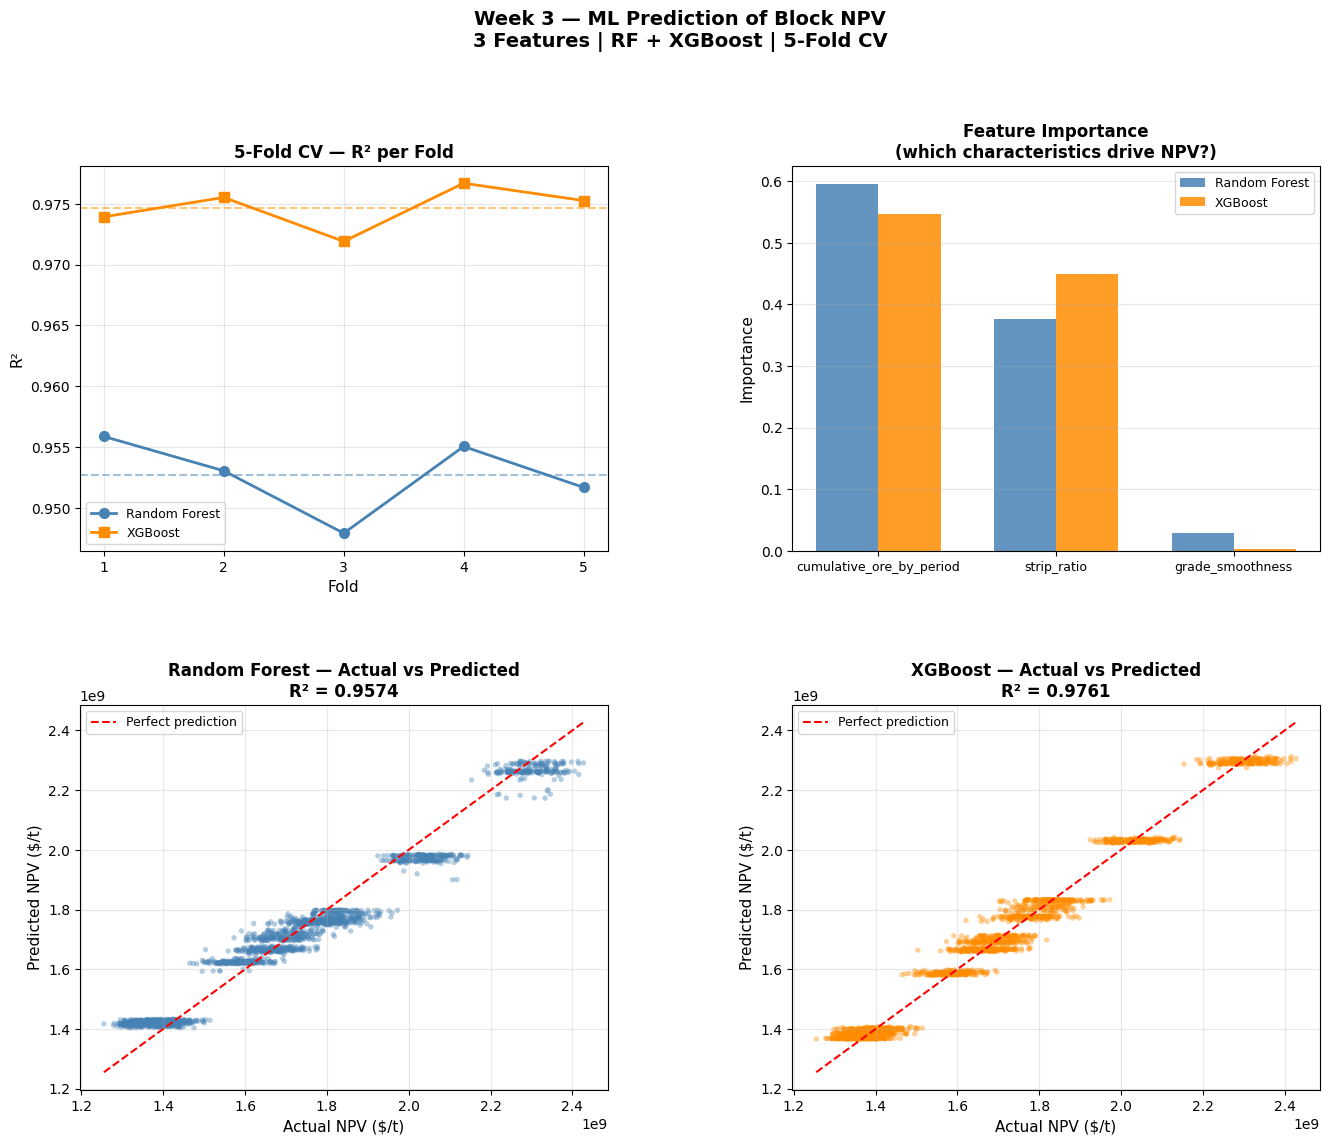

In [48]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# Plot 1: CV R² scores per fold 
ax1 = fig.add_subplot(gs[0, 0])
folds = np.arange(1, 6)
ax1.plot(folds, cv_results['Random Forest']['R2'], 'o-', color='steelblue',
         linewidth=2, markersize=7, label='Random Forest')
ax1.plot(folds, cv_results['XGBoost']['R2'],       's-', color='darkorange',
         linewidth=2, markersize=7, label='XGBoost')
ax1.axhline(cv_results['Random Forest']['R2'].mean(), color='steelblue',
            linestyle='--', alpha=0.5)
ax1.axhline(cv_results['XGBoost']['R2'].mean(),       color='darkorange',
            linestyle='--', alpha=0.5)
ax1.set_xlabel('Fold', fontsize=11)
ax1.set_ylabel('R²', fontsize=11)
ax1.set_title('5-Fold CV — R² per Fold', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_xticks(folds)
ax1.grid(alpha=0.3)

# Plot 2: Feature Importance 
ax2 = fig.add_subplot(gs[0, 1])
x_pos = np.arange(len(FEATURES))
width = 0.35
ax2.bar(x_pos - width/2, importance_df['Random Forest'], width,
        label='Random Forest', color='steelblue', alpha=0.85)
ax2.bar(x_pos + width/2, importance_df['XGBoost'],       width,
        label='XGBoost',       color='darkorange', alpha=0.85)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(importance_df.index, fontsize=9)
ax2.set_ylabel('Importance', fontsize=11)
ax2.set_title('Feature Importance\n(which characteristics drive NPV?)',
               fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Actual vs Predicted — Random Forest 
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(y, ml_df['rf_pred'], alpha=0.4, s=15, color='steelblue', edgecolors='none')
lims = [min(y.min(), ml_df['rf_pred'].min()), max(y.max(), ml_df['rf_pred'].max())]
ax3.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax3.set_xlabel('Actual NPV ($/t)', fontsize=11)
ax3.set_ylabel('Predicted NPV ($/t)', fontsize=11)
ax3.set_title(f'Random Forest — Actual vs Predicted\nR² = {r2_score(y, ml_df["rf_pred"]):.4f}',
               fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

# Plot 4: Actual vs Predicted — XGBoost 
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(y, ml_df['xgb_pred'], alpha=0.4, s=15, color='darkorange', edgecolors='none')
ax4.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax4.set_xlabel('Actual NPV ($/t)', fontsize=11)
ax4.set_ylabel('Predicted NPV ($/t)', fontsize=11)
ax4.set_title(f'XGBoost — Actual vs Predicted\nR² = {r2_score(y, ml_df["xgb_pred"]):.4f}',
               fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

fig.suptitle('Week 3 — ML Prediction of Block NPV\n3 Features | RF + XGBoost | 5-Fold CV',
              fontsize=14, fontweight='bold', y=1.01)

plt.savefig('week3_ml_plots.png', dpi=150, bbox_inches='tight')
plt.show()

Save the Best Model

We save whichever model has the better CV R² as `npv_predictor.pkl`.

In [49]:
rf_mean_r2  = cv_results['Random Forest']['R2'].mean()
xgb_mean_r2 = cv_results['XGBoost']['R2'].mean()

if rf_mean_r2 >= xgb_mean_r2:
    best_model      = rf_model
    best_model_name = 'Random Forest'
    best_r2         = rf_mean_r2
else:
    best_model      = xgb_model
    best_model_name = 'XGBoost'
    best_r2         = xgb_mean_r2

# Save as pickle
with open('models/npv_predictor.pkl', 'wb') as f:
    pickle.dump({'model': best_model, 'features': FEATURES, 'model_name': best_model_name}, f)

print(f'Best model : {best_model_name}  (CV R² = {best_r2:.4f})')
print(f'Saved to   : models/npv_predictor.pkl')

# Also save enriched dataframe for Week 4
df.to_csv('block_model_with_ml.csv', index=False)
print(f'Enriched block model saved → block_model_with_ml.csv')

Best model : XGBoost  (CV R² = 0.9747)
Saved to   : models/npv_predictor.pkl
Enriched block model saved → block_model_with_ml.csv
